In [1]:
import pandas as pd
df = pd.read_csv("/Users/ayeshashimu/Downloads/invoices_real.csv")
df.head()

,invoice_id,vendor_name,category,payment_terms,region,invoice_date,due_date,payment_date,amount,dispute_flag
0,INV-101890,Gringotts,Office,90,East,2022-06-06,2022-09-04,2022-09-12,1919.0,NaN
1,INV-100626,Sterling Cooper,Consulting,15,East,2024-05-08,2024-05-23,2024-05-15,2636.23,NaN
2,INV-103238,Nakatomi Trading,Office,90,Central,04/17/2024,2024-07-16,NaN,2767.72,NaN
3,INV-102105,Globex Corp,Marketing,60,North,2023-03-20,2023-05-19,2023-05-16,600.15,NaN
4,INV-100111,prestige worldwide,Logistics,15,North,2022-09-03,2022-09-18,2022-09-19,10161.58,NaN


In [2]:
df.shape

(5040, 10)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5040 entries, 0 to 5039
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   invoice_id     5040 non-null   object
 1   vendor_name    5040 non-null   object
 2   category       4840 non-null   object
 3   payment_terms  5040 non-null   int64 
 4   region         4940 non-null   object
 5   invoice_date   5040 non-null   object
 6   due_date       4890 non-null   object
 7   payment_date   4617 non-null   object
 8   amount         4888 non-null   object
 9   dispute_flag   168 non-null    object
dtypes: int64(1), object(9)
memory usage: 393.9+ KB


In [4]:
df.isnull().sum()

invoice_id          0
vendor_name         0
category          200
payment_terms       0
region            100
invoice_date        0
due_date          150
payment_date      423
amount            152
dispute_flag     4872
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(40)

In [6]:
df["vendor_name"].nunique()

284

In [7]:
df = df.drop_duplicates()

In [8]:
df.shape

(5000, 10)

In [9]:
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

In [10]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")
df["due_date"]     = pd.to_datetime(df["due_date"], errors="coerce")
df["payment_date"] = pd.to_datetime(df["payment_date"], errors="coerce")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 5039
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   invoice_id     5000 non-null   object        
 1   vendor_name    5000 non-null   object        
 2   category       4800 non-null   object        
 3   payment_terms  5000 non-null   int64         
 4   region         4900 non-null   object        
 5   invoice_date   4800 non-null   datetime64[ns]
 6   due_date       4850 non-null   datetime64[ns]
 7   payment_date   4579 non-null   datetime64[ns]
 8   amount         4251 non-null   float64       
 9   dispute_flag   168 non-null    object        
dtypes: datetime64[ns](3), float64(1), int64(1), object(5)
memory usage: 429.7+ KB


In [12]:
df["vendor_name"] = df["vendor_name"].str.strip().str.title()

In [13]:
df["vendor_name"].nunique()

194

In [14]:
df["vendor_name"] = df["vendor_name"].str.replace(r"\s+", " ", regex=True)

In [15]:
df["vendor_name"].nunique()

167

In [16]:
df["days_to_pay"] = (df["payment_date"] - df["due_date"]).dt.days

In [17]:
df[["due_date", "payment_date", "days_to_pay"]].head()

,due_date,payment_date,days_to_pay
0,2022-09-04,2022-09-12,8.0
1,2024-05-23,2024-05-15,-8.0
2,2024-07-16,NaT,NaN
3,2023-05-19,2023-05-16,-3.0
4,2022-09-18,2022-09-19,1.0


In [18]:
model_df = df[df["days_to_pay"].notna()]

In [19]:
model_df.shape

(4442, 11)

In [20]:
model_df["days_to_pay"].describe()

count    4442.000000
mean        4.853670
std        15.536889
min       -12.000000
25%        -6.000000
50%         1.500000
75%        10.000000
max        90.000000
Name: days_to_pay, dtype: float64

In [21]:
X = model_df[["amount", "payment_terms"]]
y = model_df["days_to_pay"]

In [22]:
X = X.fillna(X.median())

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X_train.shape, X_test.shape

((3553, 2), (889, 2))

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
predictions = model.predict(X_test)

In [27]:
predictions[:5]

array([4.60028408, 4.58640994, 4.96108233, 4.39912913, 4.74747841])

In [28]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print(mae)

11.707598410832734


In [29]:
baseline = [y_train.mean()] * len(y_test)
baseline_mae = mean_absolute_error(y_test, baseline)
print(baseline_mae)

11.726995074109967


In [30]:
features = model_df[["amount", "payment_terms", "vendor_name", "category", "region"]]
X = pd.get_dummies(features, columns=["vendor_name", "category", "region"])
X = X.fillna(X.median())

In [31]:
X.shape

(4442, 176)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
new_predictions = model.predict(X_test)
new_mae = mean_absolute_error(y_test, new_predictions)
print(new_mae)

10.691618788465984


In [33]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)
forest_predictions = forest.predict(X_test)
forest_mae = mean_absolute_error(y_test, forest_predictions)
print(forest_mae)

11.827519926080667


In [34]:
!pip install xgboost

zsh:1: command not found: pip


In [35]:
%pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)
xgb_predictions = xgb.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
print(xgb_mae)

10.905993447333147


### What are we predicting?
Most invoices get paid close to their due date, but a few are paid very late.
That long tail of late payments is what costs finance teams time and money.

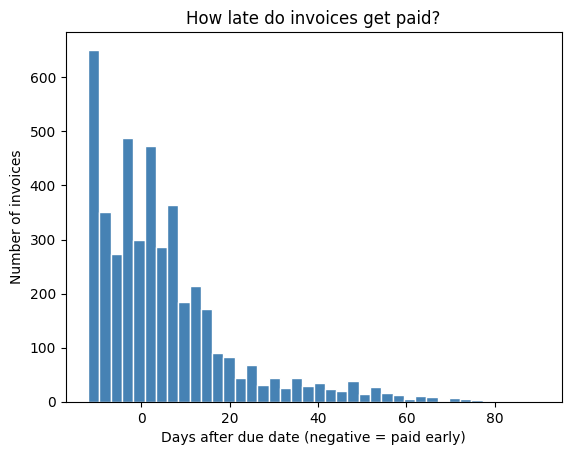

In [37]:
import matplotlib.pyplot as plt

plt.hist(model_df["days_to_pay"], bins=40, color="steelblue", edgecolor="white")
plt.title("How late do invoices get paid?")
plt.xlabel("Days after due date (negative = paid early)")
plt.ylabel("Number of invoices")
plt.show()

### Who pays slowest?
Some vendors are reliably slow. Knowing this, finance can chase these vendors
earlier instead of treating every invoice the same.

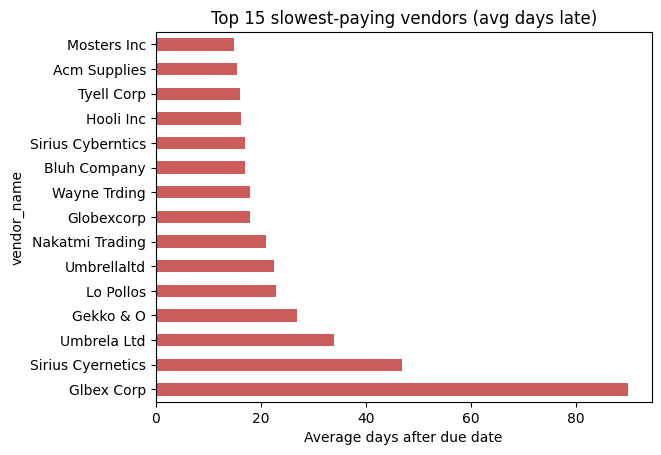

In [38]:
vendor_lateness = model_df.groupby("vendor_name")["days_to_pay"].mean().sort_values(ascending=False).head(15)

vendor_lateness.plot(kind="barh", color="indianred")
plt.title("Top 15 slowest-paying vendors (avg days late)")
plt.xlabel("Average days after due date")
plt.show()

### Did the model work?
I tested four approaches. The simplest (Linear Regression) won.
All models landed around the same score — a sign of a data ceiling, not a modeling failure.

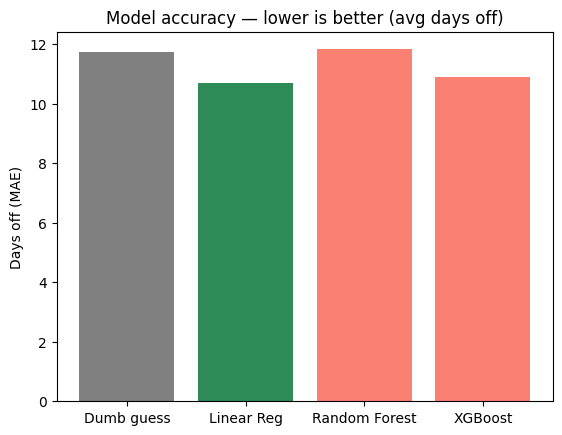

In [39]:
scores = {"Dumb guess": 11.73, "Linear Reg": 10.69, "Random Forest": 11.83, "XGBoost": 10.91}

plt.bar(scores.keys(), scores.values(), color=["grey", "seagreen", "salmon", "salmon"])
plt.title("Model accuracy — lower is better (avg days off)")
plt.ylabel("Days off (MAE)")
plt.show()

# 📄 Invoice Payment Prediction

**The problem:** Finance teams don't know which invoices will be paid late, so they chase everyone — wasting time.

**What this does:** Predicts how many days an invoice will take to get paid, so finance can flag the risky ones early.

**The result:** Predicts payment timing within ~11 days on average. A simple model won — and all models hit a natural ceiling because the biggest causes of late payment (disputes, cash-flow problems) aren't recorded in the data.

**Tools:** Python · pandas · scikit-learn · XGBoost · matplotlib

### ⚠️ Limitations (what this can't do)
The biggest reasons invoices are paid late — disputes, customer cash-flow problems,
phone calls — are not recorded in the data. So no model can predict perfectly.
This tool narrows the guess; it doesn't replace human judgment.

In [43]:
model_df["is_late"] = (model_df["days_to_pay"] > 0).astype(int)
model_df["is_late"].value_counts()

/var/folders/96/lbx62_9n3rbb77bhp69bz2l80000gq/T/ipykernel_61815/1962579887.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df["is_late"] = (model_df["days_to_pay"] > 0).astype(int)


is_late
1    2380
0    2062
Name: count, dtype: int64

In [44]:
model_df = df[df["days_to_pay"].notna()].copy()
model_df["is_late"] = (model_df["days_to_pay"] > 0).astype(int)

In [45]:
from sklearn.linear_model import LogisticRegression

y_late = model_df["is_late"]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_late, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_c, y_train_c)
late_preds = clf.predict(X_test_c)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train_c)
late_preds = clf.predict(X_test_scaled)

In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_c, late_preds)
print(accuracy)

0.6872890888638921


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test_c, late_preds))

              precision    recall  f1-score   support

           0       0.66      0.61      0.63       393
           1       0.71      0.75      0.73       496

    accuracy                           0.69       889
   macro avg       0.68      0.68      0.68       889
weighted avg       0.69      0.69      0.69       889



In [49]:
import joblib

joblib.dump(model, "reg_model.pkl")
joblib.dump(clf, "clf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

['feature_columns.pkl']

In [50]:
import os
print([f for f in os.listdir() if f.endswith(".pkl")])

['scaler.pkl', 'feature_columns.pkl', 'reg_model.pkl', 'clf_model.pkl']


In [51]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

reg_model = joblib.load("reg_model.pkl")
clf_model = joblib.load("clf_model.pkl")
scaler = joblib.load("scaler.pkl")
columns = joblib.load("feature_columns.pkl")

vendors    = [c.replace("vendor_name_", "") for c in columns if c.startswith("vendor_name_")]
categories = [c.replace("category_", "")    for c in columns if c.startswith("category_")]
regions    = [c.replace("region_", "")      for c in columns if c.startswith("region_")]

st.title("📄 Invoice Payment Predictor")
st.write("Fill in an invoice and I'll predict when it'll be paid.")

vendor   = st.selectbox("Vendor", sorted(vendors))
category = st.selectbox("Category", sorted(categories))
region   = st.selectbox("Region", sorted(regions))
amount   = st.number_input("Amount", min_value=0.0, value=1000.0)
terms    = st.selectbox("Payment terms (days)", [15, 30, 45, 60, 90])

if st.button("Predict"):
    row = pd.DataFrame(np.zeros((1, len(columns))), columns=columns)
    row["amount"] = amount
    row["payment_terms"] = terms
    if f"vendor_name_{vendor}" in row: row[f"vendor_name_{vendor}"] = 1
    if f"category_{category}" in row: row[f"category_{category}"] = 1
    if f"region_{region}" in row: row[f"region_{region}"] = 1

    days = reg_model.predict(row)[0]
    late = clf_model.predict(scaler.transform(row))[0]

    st.subheader("Prediction")
    st.write(f"⏱️ Estimated days after due date: **{days:.1f}**")
    if late == 1:
        st.error("🚨 Likely to be paid LATE")
    else:
        st.success("✅ Likely to be paid ON TIME")

2026-06-18 22:48:14.324 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 22:48:14.496 
  command:

    streamlit run /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-06-18 22:48:14.496 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 22:48:14.496 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 22:48:14.497 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 22:48:14.497 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 22:48:14.497 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18